
========== TRAIN FIXED EPSILON ==========


========== TRAIN LINEAR DECAY ==========


========== TRAIN EXPONENTIAL DECAY ==========


========== SO SANH SO BUOC ==========

Fixed epsilon      : 10.54 steps
Linear decay       : 24.67 steps
Exponential decay  : 12.95 steps


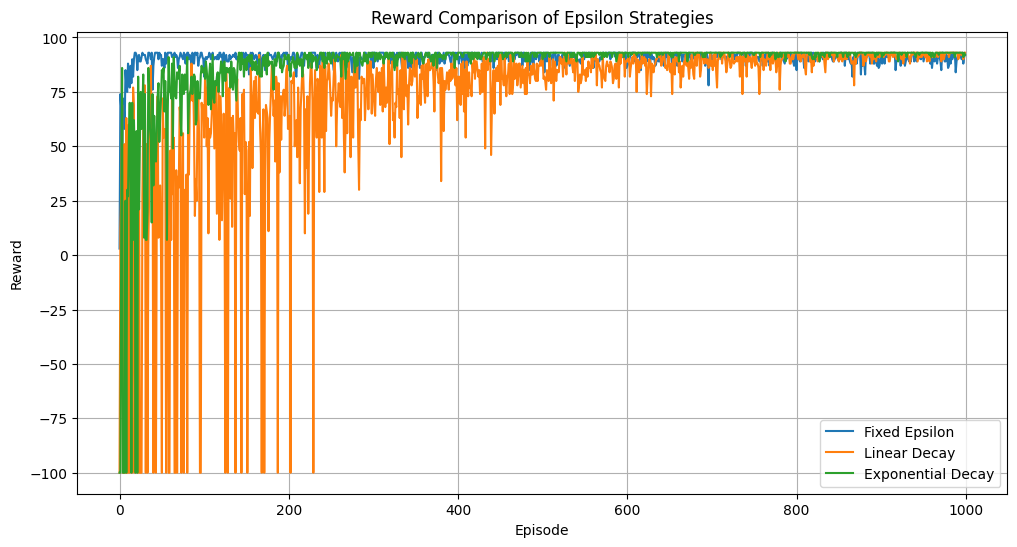


========== POLICY MAP ==========

→ → → ↓ ↓ 
↓ X → → ↓ 
↓ ← X → ↓ 
↓ X ↓ ↓ ↓ 
→ → → → G 


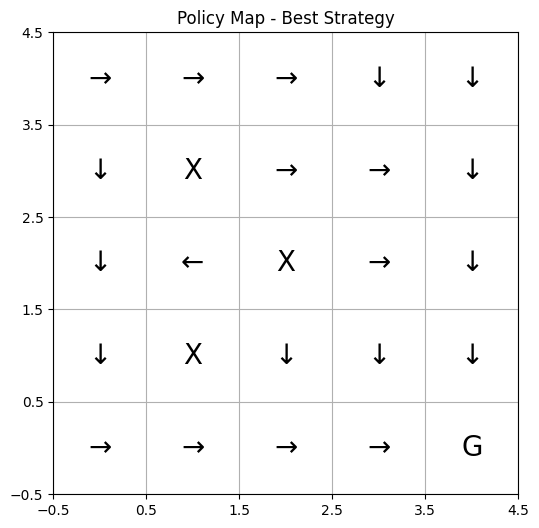


HOAN THANH PHAN B
Da tao:
- reward_comparison.png
- policy_map.png


In [3]:
# ============================================================
# PHAN_B.PY
# DE TAI 2 - HOC MAY
# Q-LEARNING VA KHAO SAT CHIEN LUOC EPSILON
# ============================================================

# ============================================================
# IMPORT THU VIEN
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import random

# ============================================================
# KHOI TAO MOI TRUONG 5x5
# ============================================================

GRID_SIZE = 5

# Vi tri bat dau
START = (0, 0)

# Vi tri dich
GOAL = (4, 4)

# Vat can
OBSTACLES = [
    (1, 1),
    (2, 2),
    (3, 1)
]

# ============================================================
# CAC HANH DONG
# 0 = UP
# 1 = DOWN
# 2 = LEFT
# 3 = RIGHT
# ============================================================

ACTIONS = [
    (-1, 0),
    (1, 0),
    (0, -1),
    (0, 1)
]

ACTION_NAMES = [
    'UP',
    'DOWN',
    'LEFT',
    'RIGHT'
]

# ============================================================
# SIEU THAM SO Q-LEARNING
# ============================================================

ALPHA = 0.3
GAMMA = 0.9

EPISODES = 1000

MAX_STEPS = 100

# ============================================================
# KHOI TAO Q-TABLE
# ============================================================

Q = np.zeros((GRID_SIZE, GRID_SIZE, 4))

# ============================================================
# HAM KIEM TRA HOP LE
# ============================================================

def is_valid_position(x, y):

    # Ngoai bien
    if x < 0 or x >= GRID_SIZE:
        return False

    if y < 0 or y >= GRID_SIZE:
        return False

    # Trung vat can
    if (x, y) in OBSTACLES:
        return False

    return True

# ============================================================
# HAM THUC HIEN HANH DONG
# ============================================================

def step(state, action):

    x, y = state

    dx, dy = ACTIONS[action]

    nx = x + dx
    ny = y + dy

    # Neu vi tri khong hop le
    if not is_valid_position(nx, ny):

        nx = x
        ny = y

    next_state = (nx, ny)

    # Reward
    if next_state == GOAL:

        reward = 100

    else:

        reward = -1

    return next_state, reward

# ============================================================
# EPSILON STRATEGY
# ============================================================

# ------------------------------------------------------------
# 1. FIXED EPSILON
# ------------------------------------------------------------

def epsilon_fixed(ep):

    return 0.2

# ------------------------------------------------------------
# 2. LINEAR DECAY
# ------------------------------------------------------------

def epsilon_linear(ep):

    eps_start = 1.0
    eps_end = 0.05

    epsilon = eps_start - (
        (eps_start - eps_end) * (ep / EPISODES)
    )

    return max(eps_end, epsilon)

# ------------------------------------------------------------
# 3. EXPONENTIAL DECAY
# ------------------------------------------------------------

def epsilon_exponential(ep):

    epsilon = 1.0 * (0.995 ** ep)

    return max(0.05, epsilon)

# ============================================================
# HAM CHON HANH DONG
# EPSILON-GREEDY
# ============================================================

def choose_action(state, epsilon):

    # Exploration
    if random.random() < epsilon:

        return random.randint(0, 3)

    # Exploitation
    x, y = state

    return np.argmax(Q[x, y])

# ============================================================
# HAM TRAIN Q-LEARNING
# ============================================================

def train_q_learning(epsilon_strategy):

    global Q

    # Reset Q-table
    Q = np.zeros((GRID_SIZE, GRID_SIZE, 4))

    rewards_per_episode = []

    steps_per_episode = []

    # ========================================================
    # TRAIN
    # ========================================================

    for ep in range(EPISODES):

        state = START

        total_reward = 0

        steps = 0

        epsilon = epsilon_strategy(ep)

        # ====================================================
        # CHAY TRONG 1 EPISODE
        # ====================================================

        for _ in range(MAX_STEPS):

            steps += 1

            # Chon hanh dong
            action = choose_action(state, epsilon)

            # Thuc hien hanh dong
            next_state, reward = step(state, action)

            x, y = state
            nx, ny = next_state

            # =================================================
            # CAP NHAT Q-TABLE
            # =================================================

            Q[x, y, action] = Q[x, y, action] + ALPHA * (

                reward +

                GAMMA * np.max(Q[nx, ny]) -

                Q[x, y, action]

            )

            # Chuyen state
            state = next_state

            total_reward += reward

            # Den GOAL
            if state == GOAL:

                break

        rewards_per_episode.append(total_reward)

        steps_per_episode.append(steps)

    # ========================================================
    # TRA VE KET QUA
    # ========================================================

    avg_steps = np.mean(steps_per_episode)

    return rewards_per_episode, avg_steps

# ============================================================
# TRAIN 3 CHIEN LUOC EPSILON
# ============================================================

print("\n========== TRAIN FIXED EPSILON ==========\n")

rewards_fixed, steps_fixed = train_q_learning(
    epsilon_fixed
)

Q_fixed = Q.copy()

# ------------------------------------------------------------

print("\n========== TRAIN LINEAR DECAY ==========\n")

rewards_linear, steps_linear = train_q_learning(
    epsilon_linear
)

Q_linear = Q.copy()

# ------------------------------------------------------------

print("\n========== TRAIN EXPONENTIAL DECAY ==========\n")

rewards_exp, steps_exp = train_q_learning(
    epsilon_exponential
)

Q_exp = Q.copy()

# ============================================================
# BANG SO SANH SO BUOC TRUNG BINH
# ============================================================

print("\n========== SO SANH SO BUOC ==========\n")

print(f"Fixed epsilon      : {steps_fixed:.2f} steps")

print(f"Linear decay       : {steps_linear:.2f} steps")

print(f"Exponential decay  : {steps_exp:.2f} steps")

# ============================================================
# VE REWARD GRAPH
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    rewards_fixed,
    label='Fixed Epsilon'
)

plt.plot(
    rewards_linear,
    label='Linear Decay'
)

plt.plot(
    rewards_exp,
    label='Exponential Decay'
)

plt.xlabel("Episode")

plt.ylabel("Reward")

plt.title("Reward Comparison of Epsilon Strategies")

plt.legend()

plt.grid(True)

# Luu hinh
plt.savefig("reward_comparison.png")

plt.show()

# ============================================================
# HIEN THI POLICY MAP
# ============================================================

print("\n========== POLICY MAP ==========\n")

# Su dung Q-table tot nhat
Q = Q_exp

arrows = [
    '↑',
    '↓',
    '←',
    '→'
]

for i in range(GRID_SIZE):

    row = ""

    for j in range(GRID_SIZE):

        # GOAL
        if (i, j) == GOAL:

            row += "G "

        # OBSTACLE
        elif (i, j) in OBSTACLES:

            row += "X "

        else:

            best_action = np.argmax(Q[i, j])

            row += arrows[best_action] + " "

    print(row)

# ============================================================
# VE POLICY MAP
# ============================================================

fig, ax = plt.subplots(figsize=(6, 6))

for i in range(GRID_SIZE):

    for j in range(GRID_SIZE):

        # GOAL
        if (i, j) == GOAL:

            text = "G"

        # OBSTACLE
        elif (i, j) in OBSTACLES:

            text = "X"

        else:

            best_action = np.argmax(Q[i, j])

            text = arrows[best_action]

        ax.text(
            j,
            GRID_SIZE - 1 - i,
            text,
            ha='center',
            va='center',
            fontsize=20
        )

# Ve luoi
ax.set_xticks(np.arange(-0.5, GRID_SIZE, 1))
ax.set_yticks(np.arange(-0.5, GRID_SIZE, 1))

ax.grid(True)

ax.set_xlim(-0.5, GRID_SIZE - 0.5)
ax.set_ylim(-0.5, GRID_SIZE - 0.5)

ax.set_title("Policy Map - Best Strategy")

# Luu hinh
plt.savefig("policy_map.png")

plt.show()

# ============================================================
# THONG BAO HOAN THANH
# ============================================================

print("\n======================================")
print("HOAN THANH PHAN B")
print("Da tao:")
print("- reward_comparison.png")
print("- policy_map.png")
print("======================================")